<a href="https://colab.research.google.com/github/paulcraig/CHMG131/blob/main/Periodic_Table_for_131.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Create Your Own Periodic Table for CHMG 131

The periodic table is a central topic for General Chemistry for Engineering Students. I found a number of resources that enable users to generate their own periodic table and have incorporated them into this Colab notebook.

* [The Periodic Table by plotnine 0.15.0](https://plotnine.org/gallery/periodic-table.html)
* [The Mendeleev PyPi Library](https://pypi.org/project/mendeleev/)
* [Creating the Periodic Table with Plotnine by Hivan du](https://medium.com/@hivan/creating-the-periodic-table-with-plotnine-6ac8f854f2bb)

### Setting Up the Notebook

In Colab (and Python notebooks in general), we need to start by installing all the libraries that we need. The code in the next cell does this. In fact, I think it has one or two libraries that are not used in this notebook.

A library is a collection of functions that is not already included in the base Python installation. This makes sense because you don't want to occupy all of your computer memory with functions that you won't be using.

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !uv pip install --system rdkit pandas numpy mendeleev plotnine[extra]

Using Python 3.13.15 environment at: /usr
Resolved 51 packages in 1.34s
Prepared 10 packages in 1.93s
Installed 10 packages in 135ms
 + adjusttext==1.4.0
 + colorama==0.4.6
 + deprecated==1.3.1
 + flexcache==0.3
 + flexparser==0.4
 + mendeleev==1.3.0
 + pint==0.24.4
 + pyfiglet==0.8.post1
 + rdkit==2026.3.6
 + scikit-misc==0.5.2


### Using RDKit
The RDKit library has many functions that are very useful to chemists, so I usually include it in all of my notebooks. The commands in the next cell import specific features of RDKit.

In [2]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import SVG


### Building the Periodic Table
The remaining code is taken ver batim from [The Periodic Table by plotnine 0.15.0](https://plotnine.org/gallery/periodic-table.html), with a few small exceptions. I have also used some of their explanations and added a few of my own.

In the first coding cell above, you installed the libraries that you need with this command

```!uv pip install --system rdkit pandas numpy mendeleev plotnine[extra]```

That's not enough. Once the libraries are installed, they must be imported into the notebook. That happens in the next frame. In the case of ```pandas``` and ```numpy```, the entire library is imported. In the case of ```plotnine```, selected functions are imported.

In [3]:
import pandas as pd
import numpy as np

from plotnine import (
    ggplot,
    aes,
    geom_tile,
    geom_text,
    scale_y_reverse,
    scale_y_discrete,
    scale_fill_brewer,
    scale_color_manual,
    coord_equal,
    theme,
    theme_void,
    element_blank,
    element_rect,
    element_text,
)



## Collecting the Data

Before we can construct a periodic table, we must collect the data for the elements. The code in the next cell pulls the elemental data from a GitHub repository as a .csv (comma separated value - a simple spreadsheet) file. The data are then imported into a ```pandas dataframe``` called elements, which is a two-dimensional array of data kind of like a spreadsheet, only much more powerful and flexible.

When looking at the code, note that lines that begin with ```#``` are comments. In fact you can also add comments to the end of a line of code (see the first line in the next cell).

In [4]:
from urllib.request import urlretrieve     # importing a method that enables retrieval of a text file from a URL

url = ("https://raw.githubusercontent.com/qiwsir/DataSet/refs/heads/master/elemanets/elements.csv")

filename = "elements.csv"

urlretrieve(url, filename)                 # pulling the data from GitHub to use it here

elements = pd.read_csv(filename)           # creating the dataframe called elements
elements                            # looking at the first five lines of the datafram

,atomic number,symbol,name,atomic mass,CPK,electronic configuration,electronegativity,atomic radius,ion radius,van der Waals radius,...,EA,standard state,bonding type,melting point,boiling point,density,metal,year discovered,group,period
0,1,H,Hydrogen,1.00794,#FFFFFF,1s1,2.20,37.0,NaN,120.0,...,-73.0,gas,diatomic,14.0,20.0,0.00009,nonmetal,1766,1,1
1,2,He,Helium,4.002602,#D9FFFF,1s2,NaN,32.0,NaN,140.0,...,0.0,gas,atomic,NaN,4.0,0.00000,noble gas,1868,18,1
2,3,Li,Lithium,6.941,#CC80FF,[He] 2s1,0.98,134.0,76 (+1),182.0,...,-60.0,solid,metallic,454.0,1615.0,0.54000,alkali metal,1817,1,2
3,4,Be,Beryllium,9.012182,#C2FF00,[He] 2s2,1.57,90.0,45 (+2),NaN,...,0.0,solid,metallic,1560.0,2743.0,1.85000,alkaline earth metal,1798,2,2
4,5,B,Boron,10.811,#FFB5B5,[He] 2s2 2p1,2.04,82.0,27 (+3),NaN,...,-27.0,solid,covalent network,2348.0,4273.0,2.46000,metalloid,1807,13,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,114,Fl,Flerovium,[289],#FF1493,[Rn].5f14.6d10.7s2.7p2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,metal,1998,14,7
114,115,Uup,Ununpentium,[288],#FF1493,[Rn].5f14.6d10.7s2.7p3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,metal,2003,15,7
115,116,Lv,Livermorium,[293],#FF1493,[Rn].5f14.6d10.7s2.7p4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,metal,2000,16,7
116,117,Uus,Ununseptium,[294],#FF1493,[Rn].5f14.6d10.7s2.7p5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,halogen,2010,17,7


### Getting the Data Ready for Display

Three common data types in Python are strings (text), int's (integers) and float64's (decimals). In addition there are many other data types or classifications in specific data structures. In the next cell, we'll use the ```dtypes``` command to determine the data type in each of the columns of the ```elements dataframe```.

In [5]:
datatypes = elements.dtypes
datatypes

,0
atomic number,int64
symbol,object
name,object
atomic mass,object
CPK,object
electronic configuration,object
electronegativity,float64
atomic radius,float64
ion radius,object
van der Waals radius,float64


### Changing Datatypes

For the purpose of the periodic table, the authors chose change four of the columns in the ```elements dataframe```.

1. In the ```group``` column all the elements have a value between 1 and 18, except the lanthanides and actinides, which technically have no group and have a value of ```-``` in the ```group``` column. For the purpose of controlling the subsequent plots, the authors chose to change the ```-``` to a ```-1```.
1. The chose to change the ```bonding type``` column from an ```object``` to a ```category.
1. They changed the ```metal``` column from an ```object``` to a ```category```.
1. They added one more column to the ```elements dataframe``` called ```atomic_number``` where they convert the ```atomic number``` in the first column from an int64 to a string in the last column.

In [6]:
elements["group"] = [-1 if g == "-" else int(g) for g in elements.group]
elements["bonding type"] = elements["bonding type"].astype("category")
elements["metal"] = elements["metal"].astype("category")
elements["atomic_number"] = elements["atomic number"].astype(str)

In [7]:
# Checking to see that the changes too effect.

datatypes = elements.dtypes
datatypes

,0
atomic number,int64
symbol,object
name,object
atomic mass,object
CPK,object
electronic configuration,object
electronegativity,float64
atomic radius,float64
ion radius,object
van der Waals radius,float64


# Creating the Top and Bottom of the Periodic Table

The next step in creating the table is to separate the top of the periodic table from the bottom, which contains the lanthanides and actinides. They did this by assigning a value of ```-1``` to the group for the lanthanides and actinides and then created separate ```dataframes``` for the top and bottom of the periodic table.


In [8]:
top = elements.query("group != -1").copy()
bottom = elements.query("group == -1").copy()

#top.head()              # You can remove the pound sign to see the top of either dataframe.
#bottom.head()

In [9]:
top["x"] = top.group
top["y"] = top.period

In [10]:
nrows = 2
hshift = 3.5
vshift = 3
bottom["x"] = np.tile(np.arange(len(bottom) // nrows), nrows) + hshift
bottom["y"] = bottom.period + vshift

In [11]:
tile_width = 0.95
tile_height = 0.95

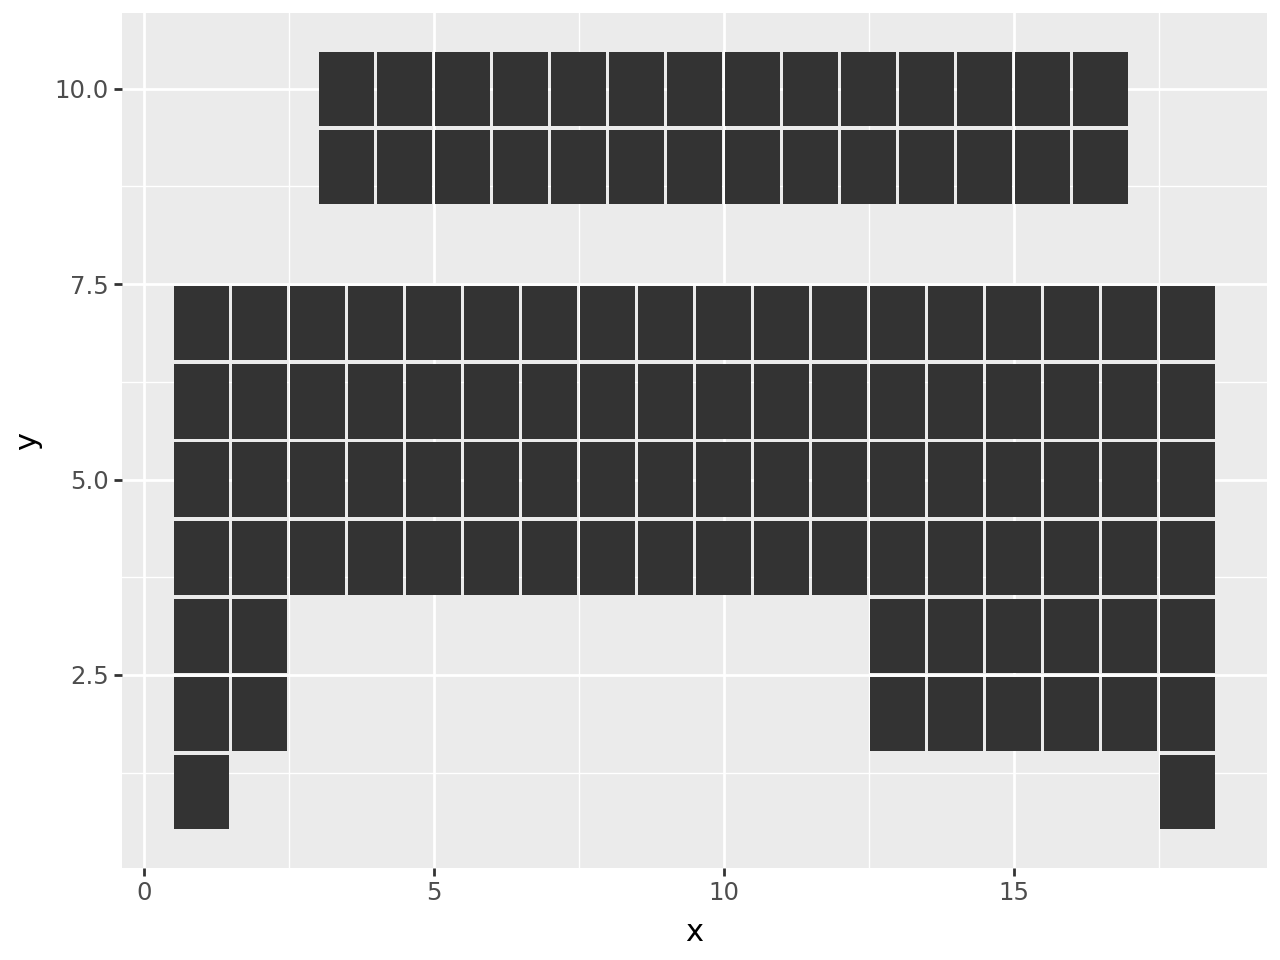

In [12]:
(
    ggplot(top, aes("x", "y"))
    + geom_tile(aes(x="x", y="y", width=tile_width, height=tile_height))
    + geom_tile(bottom, aes(x="x", y="y", width=tile_width, height=tile_height))
)

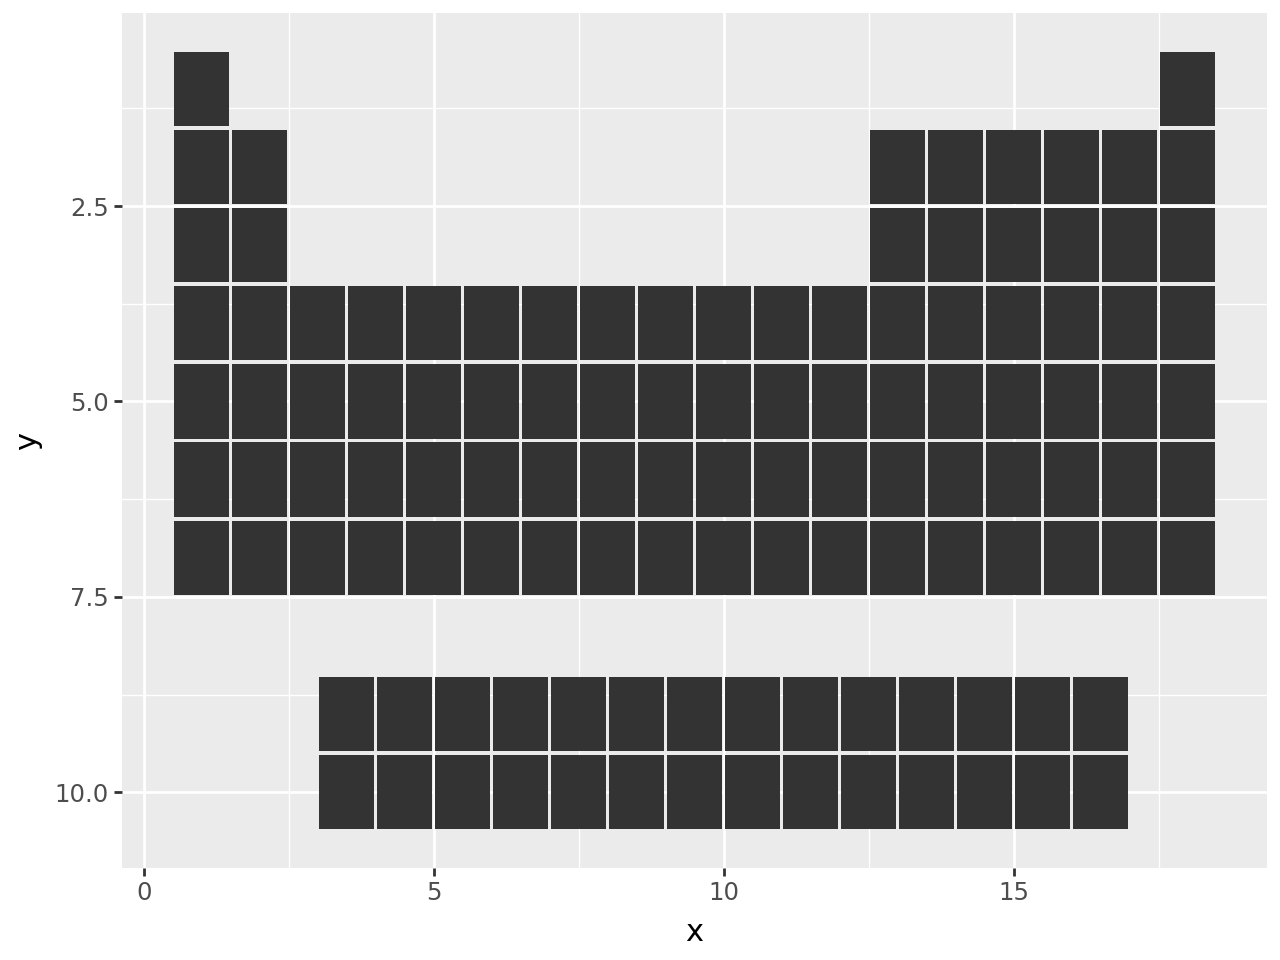

In [13]:
(
    ggplot(aes("x", "y"))
    + geom_tile(top, aes(width=tile_width, height=tile_height))
    + geom_tile(bottom, aes(width=tile_width, height=tile_height))
    + scale_y_reverse()  # new
)

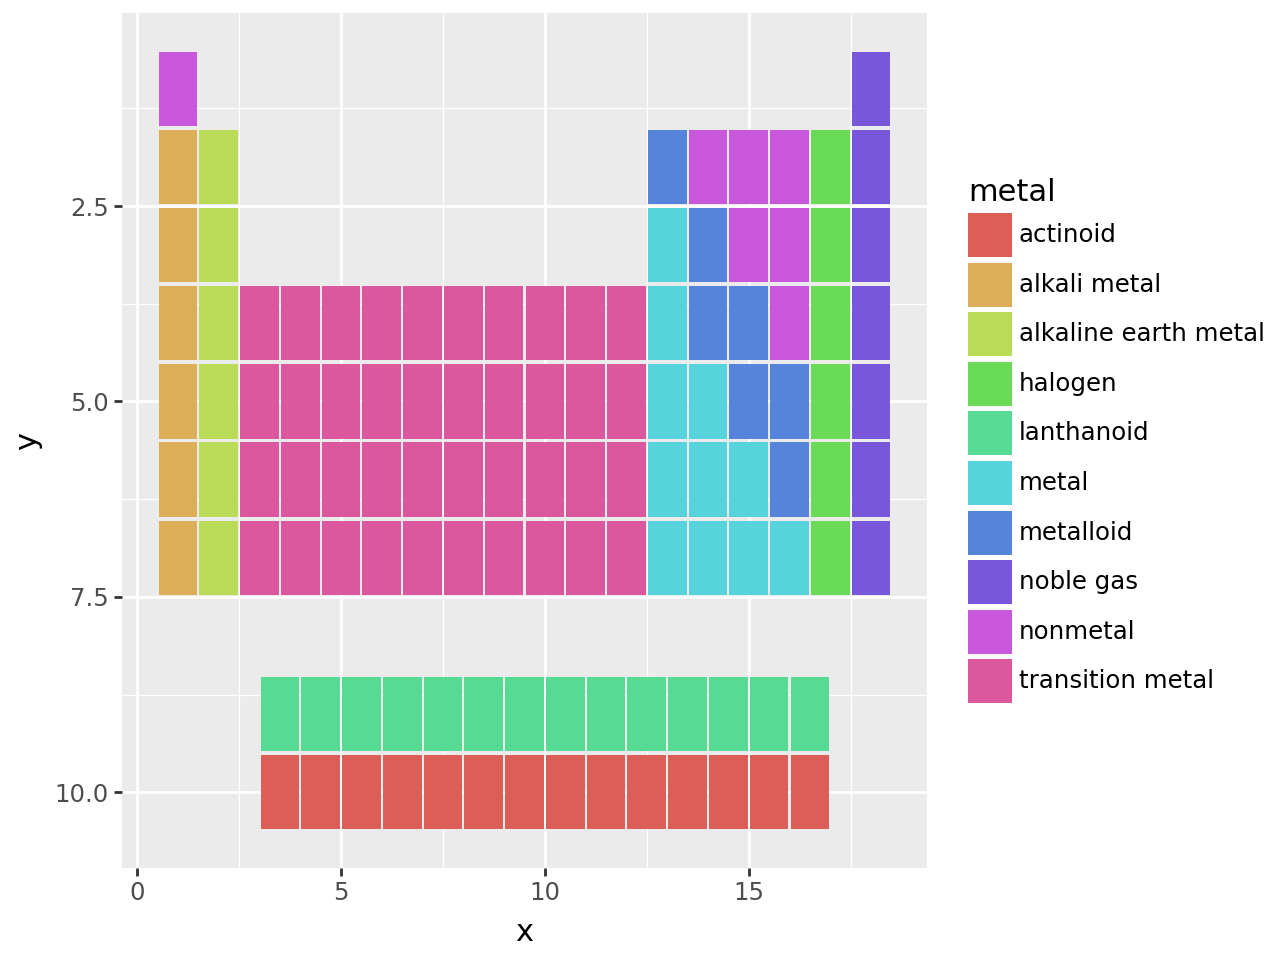

In [14]:
(
    ggplot(aes("x", "y"))
    + aes(fill="metal")  # new
    + geom_tile(top, aes(width=tile_width, height=tile_height))
    + geom_tile(bottom, aes(width=tile_width, height=tile_height))
    + scale_y_reverse()
)

In [15]:
def inner_text(data):
    layers = [
        geom_text(
            data,
            aes(label="atomic_number"),
            nudge_x=-0.40,
            nudge_y=0.40,
            ha="left",
            va="top",
            fontweight="normal",
            size=6,
        ),
        geom_text(data, aes(label="symbol"), nudge_y=0.1, size=9),
        geom_text(
            data, aes(label="name"), nudge_y=-0.125, fontweight="normal", size=4.5
        ),
        geom_text(
            data, aes(label="atomic mass"), nudge_y=-0.3, fontweight="normal", size=4.5
        ),
    ]
    return layers

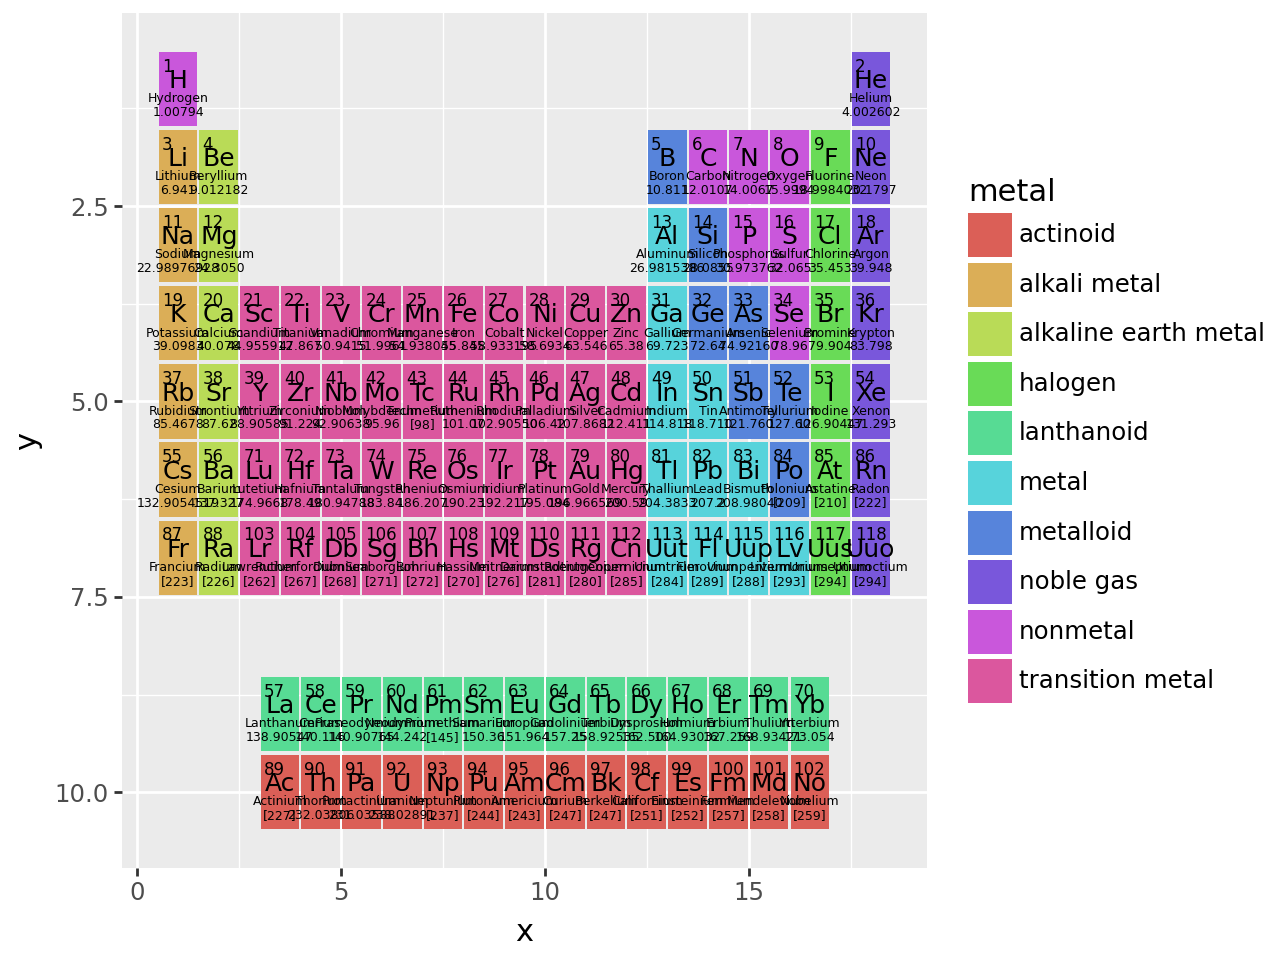

In [16]:
(
    ggplot(aes("x", "y"))
    + aes(fill="metal")
    + geom_tile(top, aes(width=tile_width, height=tile_height))
    + geom_tile(bottom, aes(width=tile_width, height=tile_height))
    + inner_text(top)  # new
    + inner_text(bottom)  # new
    + scale_y_reverse()
)

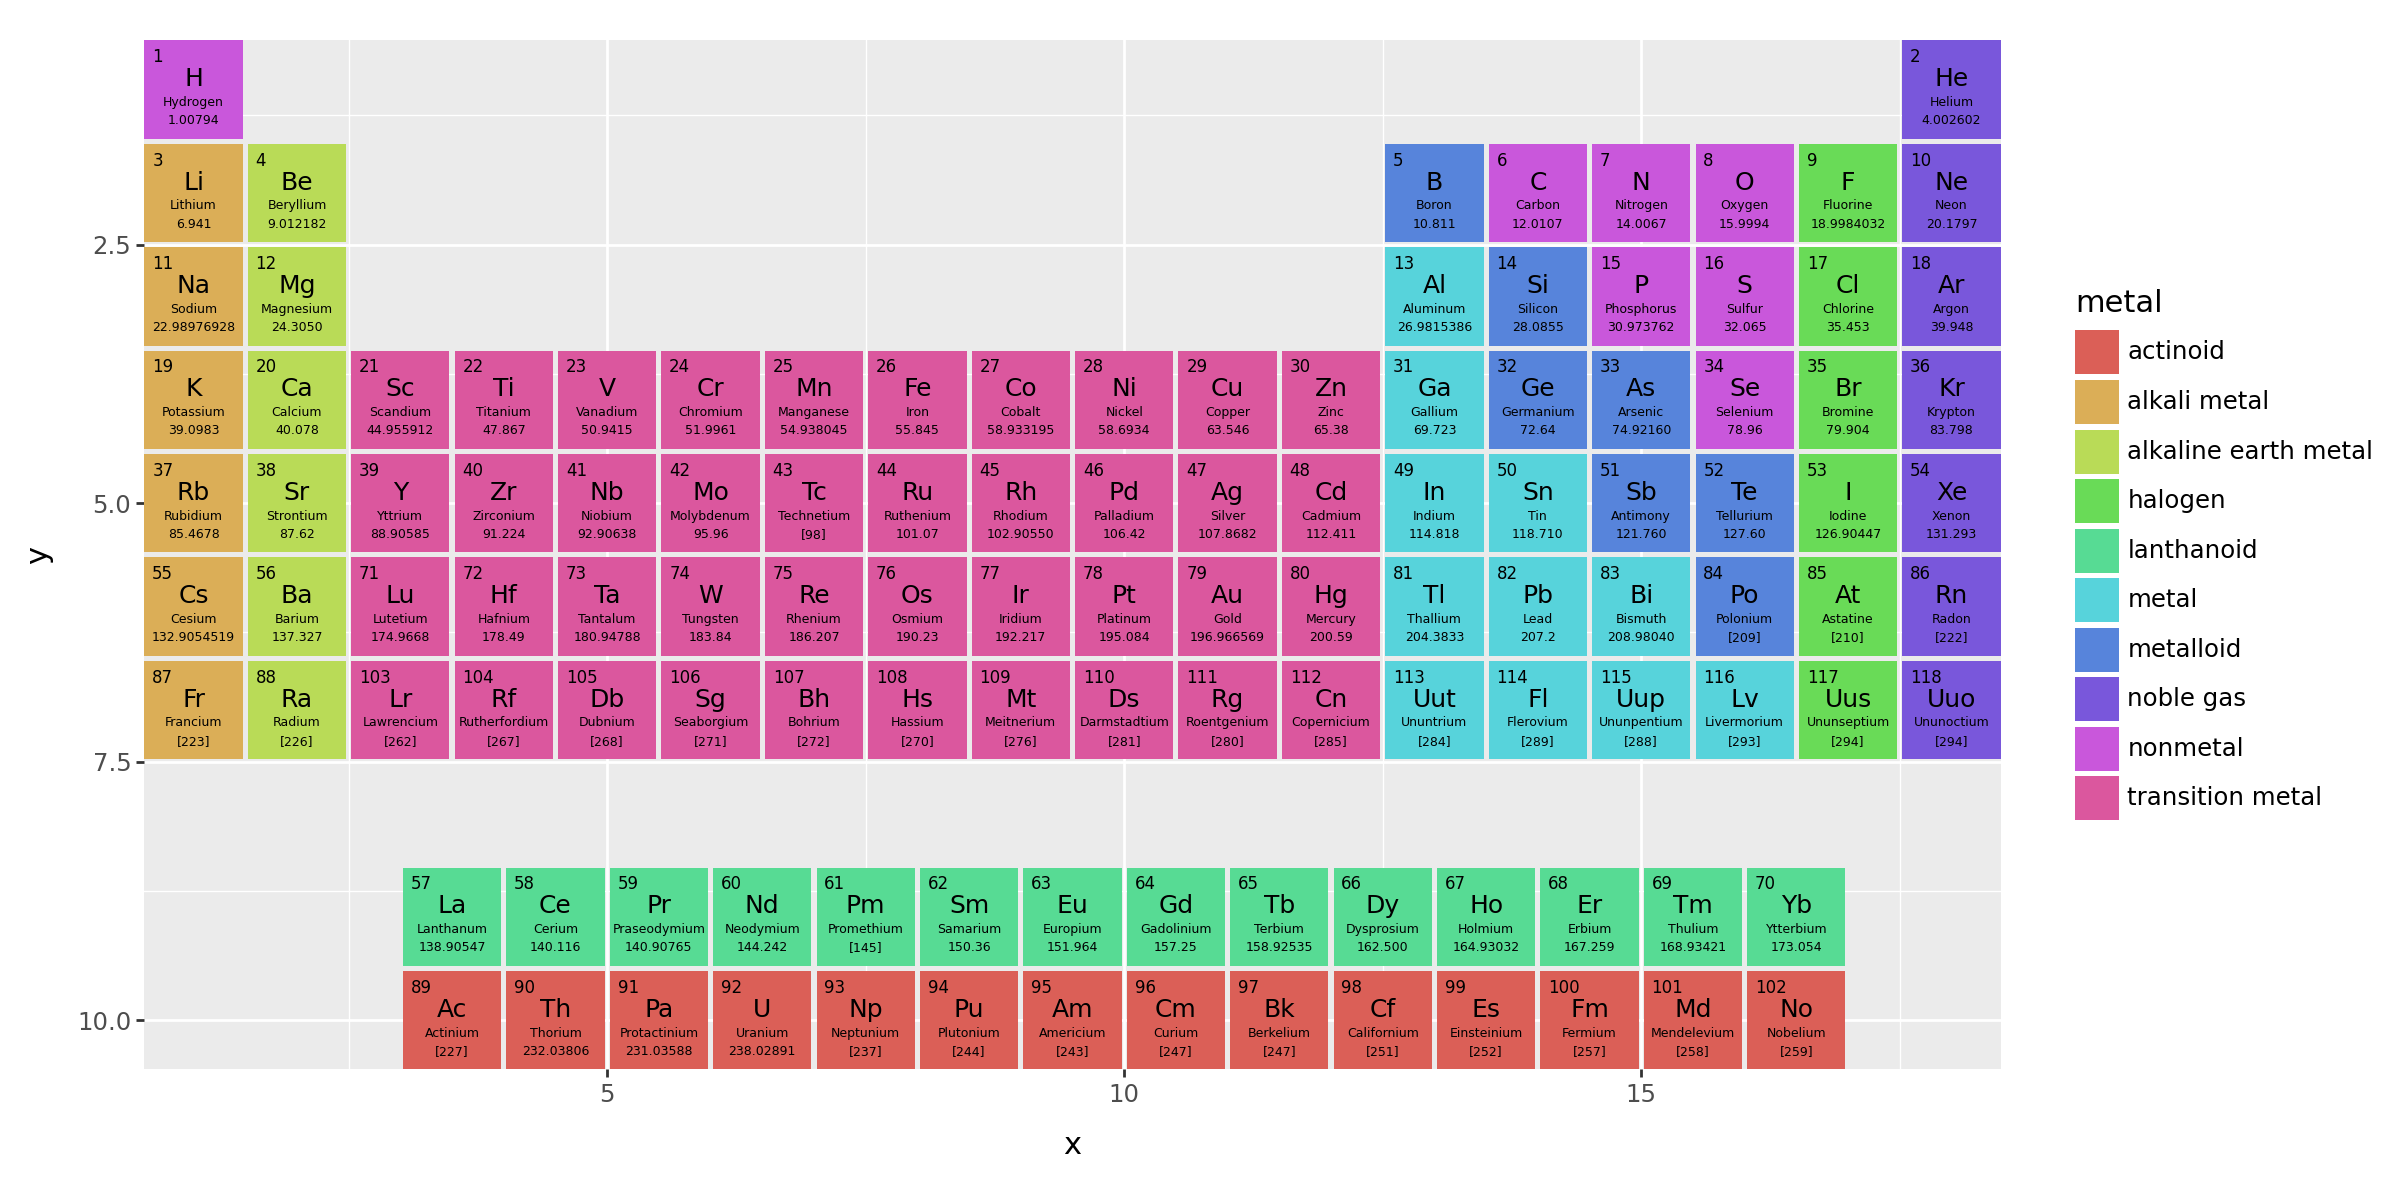

In [17]:
(
    ggplot(aes("x", "y"))
    + aes(fill="metal")
    + geom_tile(top, aes(width=tile_width, height=tile_height))
    + geom_tile(bottom, aes(width=tile_width, height=tile_height))
    + inner_text(top)
    + inner_text(bottom)
    + scale_y_reverse()
    + coord_equal(expand=False)  # new
    + theme(figure_size=(12, 6))  # new
)

In [18]:
split_df = pd.DataFrame(
    {
        "x": 3 - tile_width / 4,
        "y": [6, 7],
        "metal": pd.Categorical(["lanthanoid", "actinoid"]),
    }
)

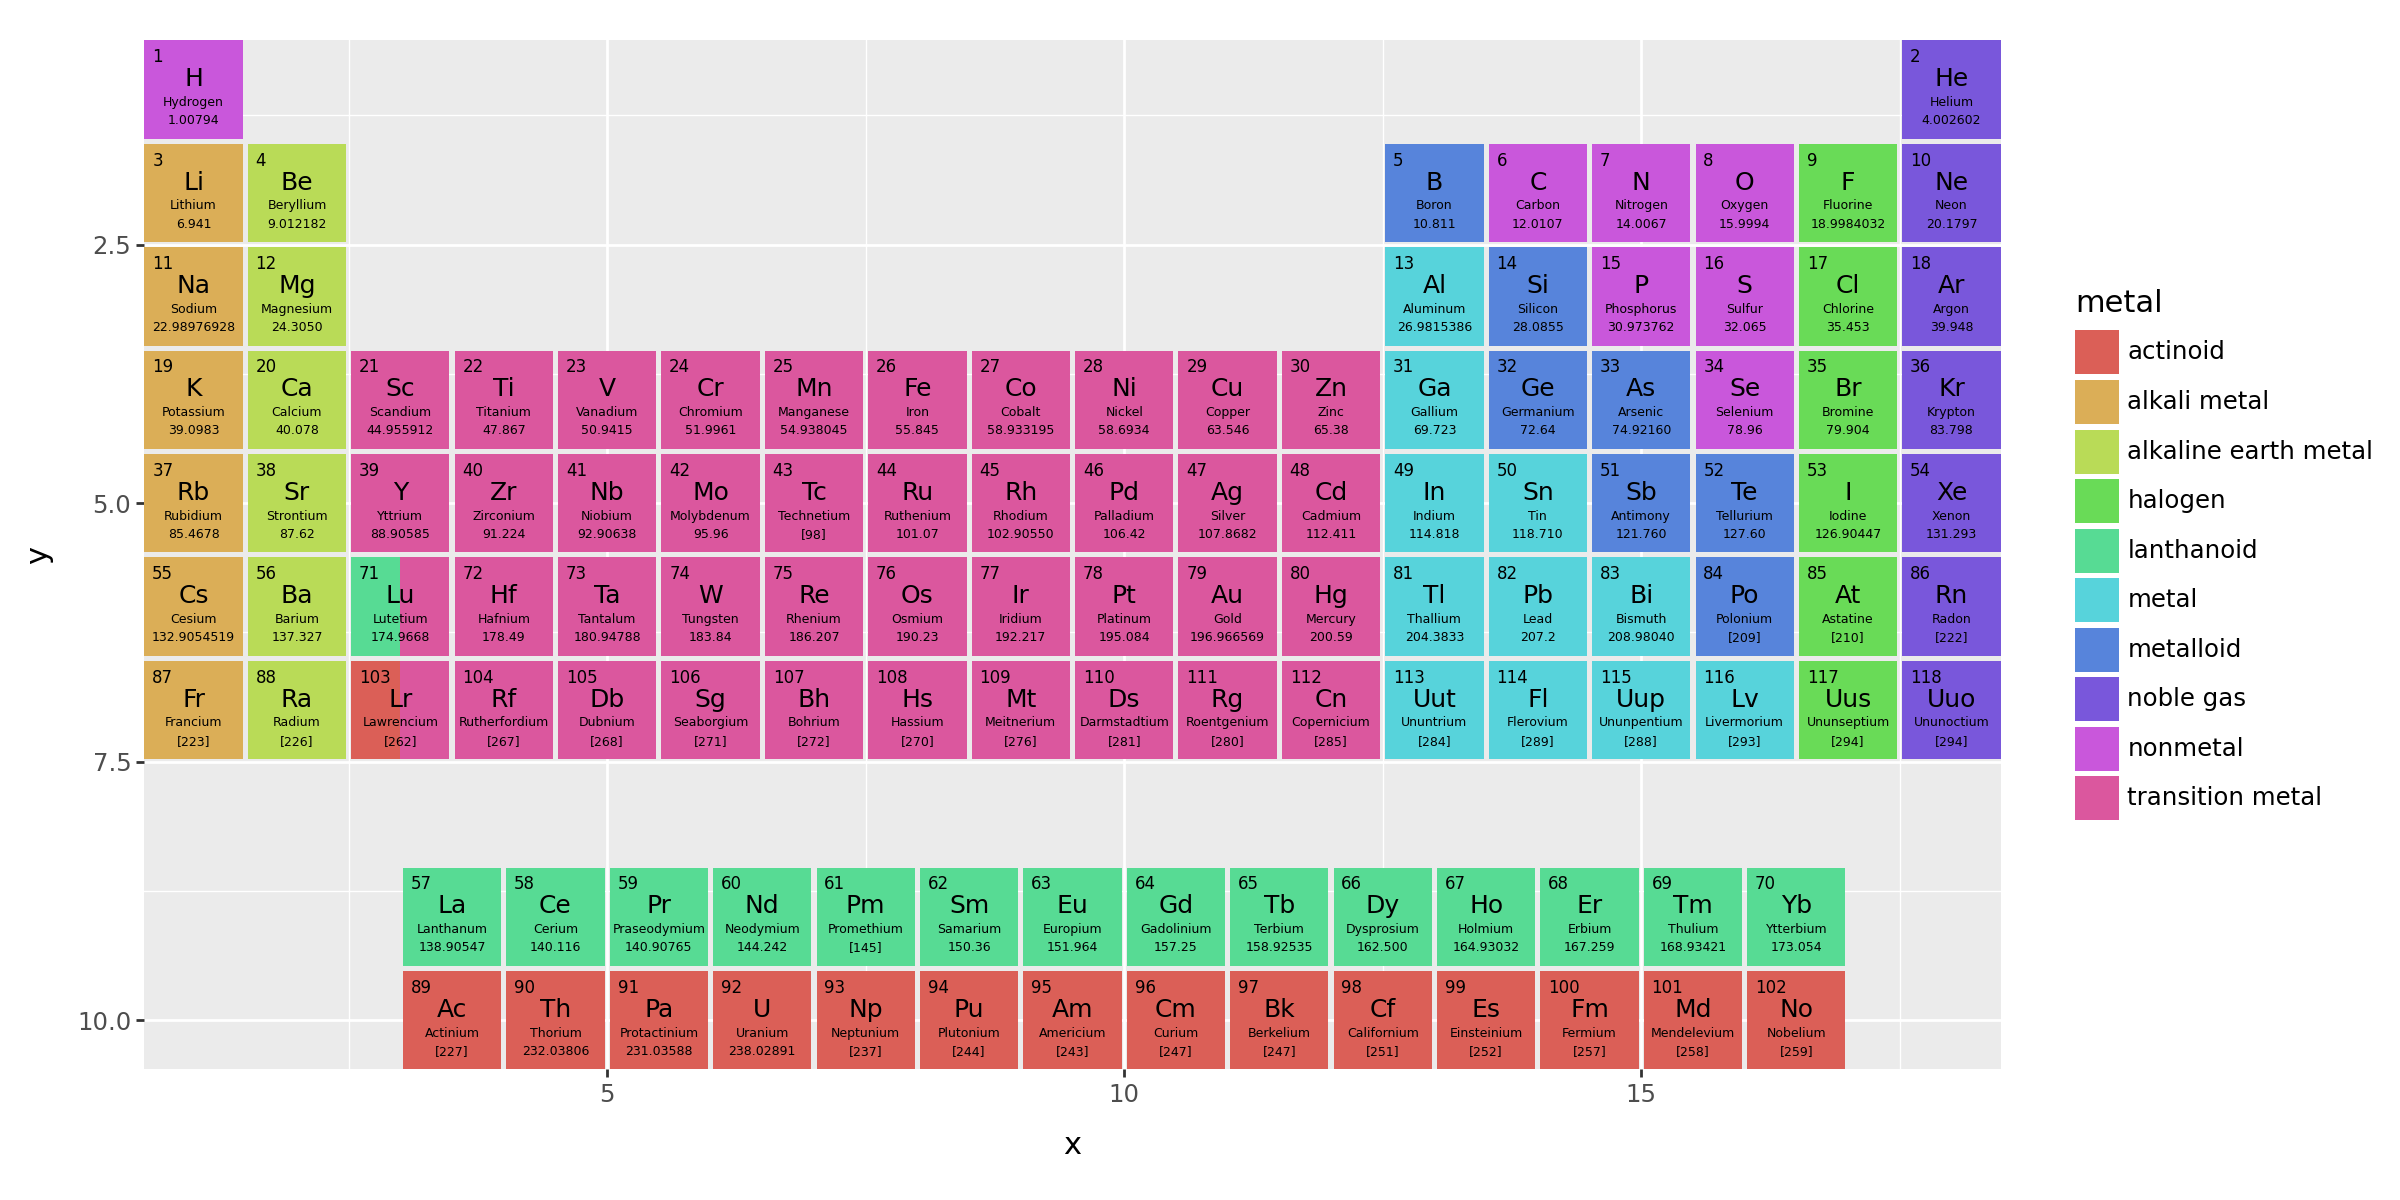

In [19]:
(
    ggplot(aes("x", "y"))
    + aes(fill="metal")
    + geom_tile(top, aes(width=tile_width, height=tile_height))
    + geom_tile(split_df, aes(width=tile_width / 2, height=tile_height))  # new
    + geom_tile(bottom, aes(width=tile_width, height=tile_height))
    + inner_text(top)
    + inner_text(bottom)
    + scale_y_reverse()
    + coord_equal(expand=False)
    + theme(figure_size=(12, 6))
)

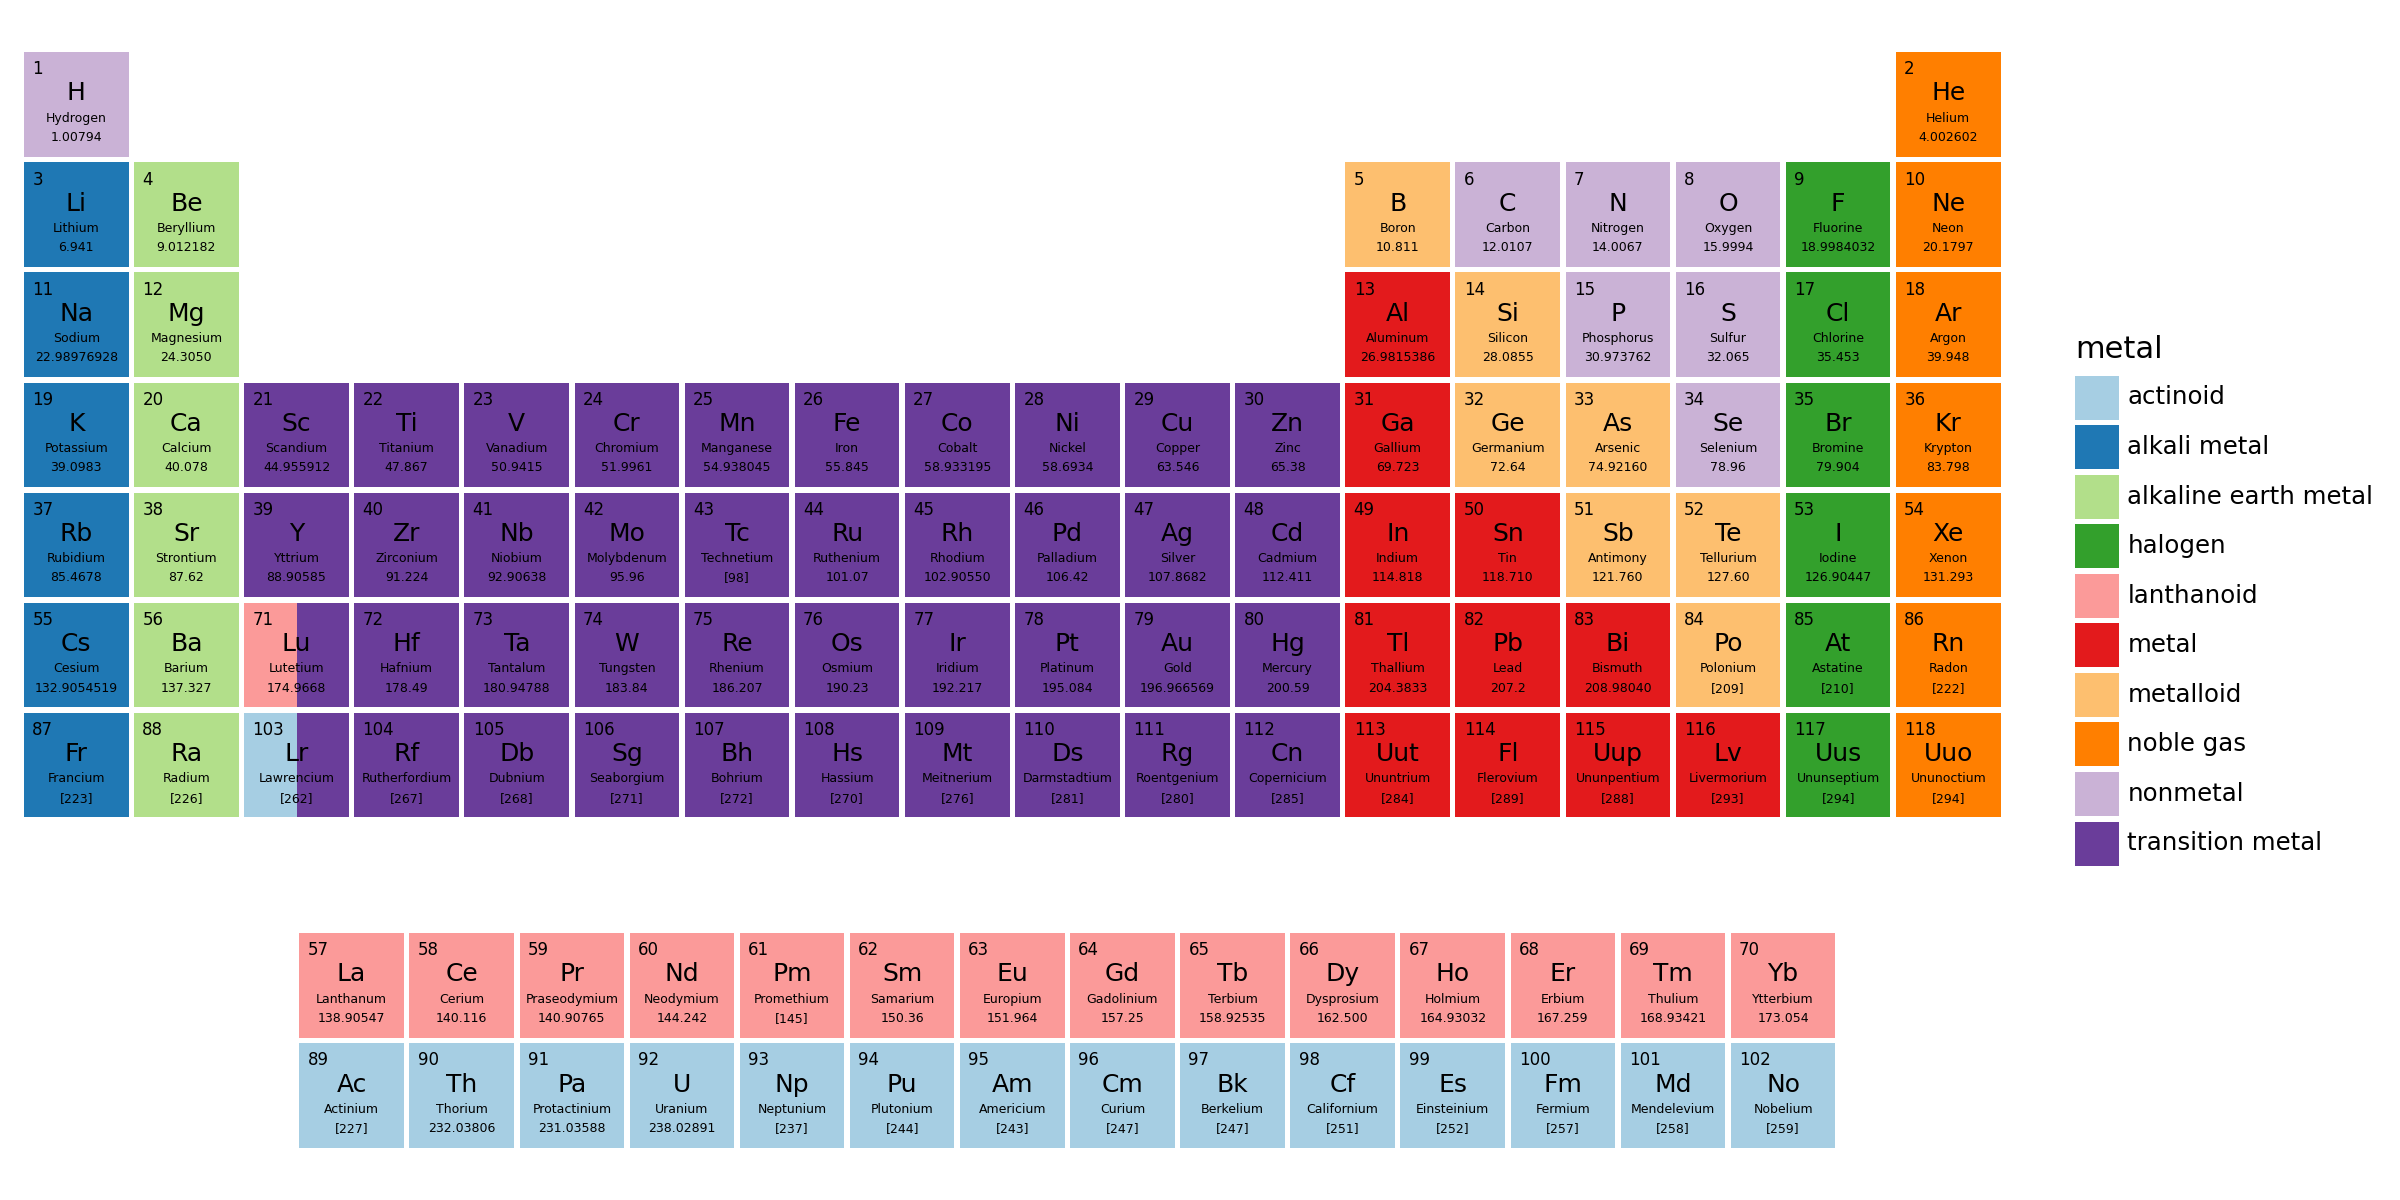

In [20]:
from plotnine import guides
(
    ggplot(aes("x", "y"))
    + aes(fill="metal")
    + geom_tile(top, aes(width=tile_width, height=tile_height))
    + geom_tile(split_df, aes(width=tile_width / 2, height=tile_height))
    + geom_tile(bottom, aes(width=tile_width, height=tile_height))
    + inner_text(top)
    + inner_text(bottom)
    + scale_y_reverse()
    + scale_fill_brewer(type="qual", palette=3)  # new
    + coord_equal(expand=False)
    + theme_void()  # new
    + theme(
        figure_size=(12, 6),
        plot_margin_left=0.01,
        plot_margin_right=0.01,
        plot_background=element_rect(fill="white"),
    )  # new
)

In [21]:
# The location of the group number is the top most (and therefore smallest period)
# element with the group
groupdf = top.groupby("group").agg(y=("period", "min")).reset_index()

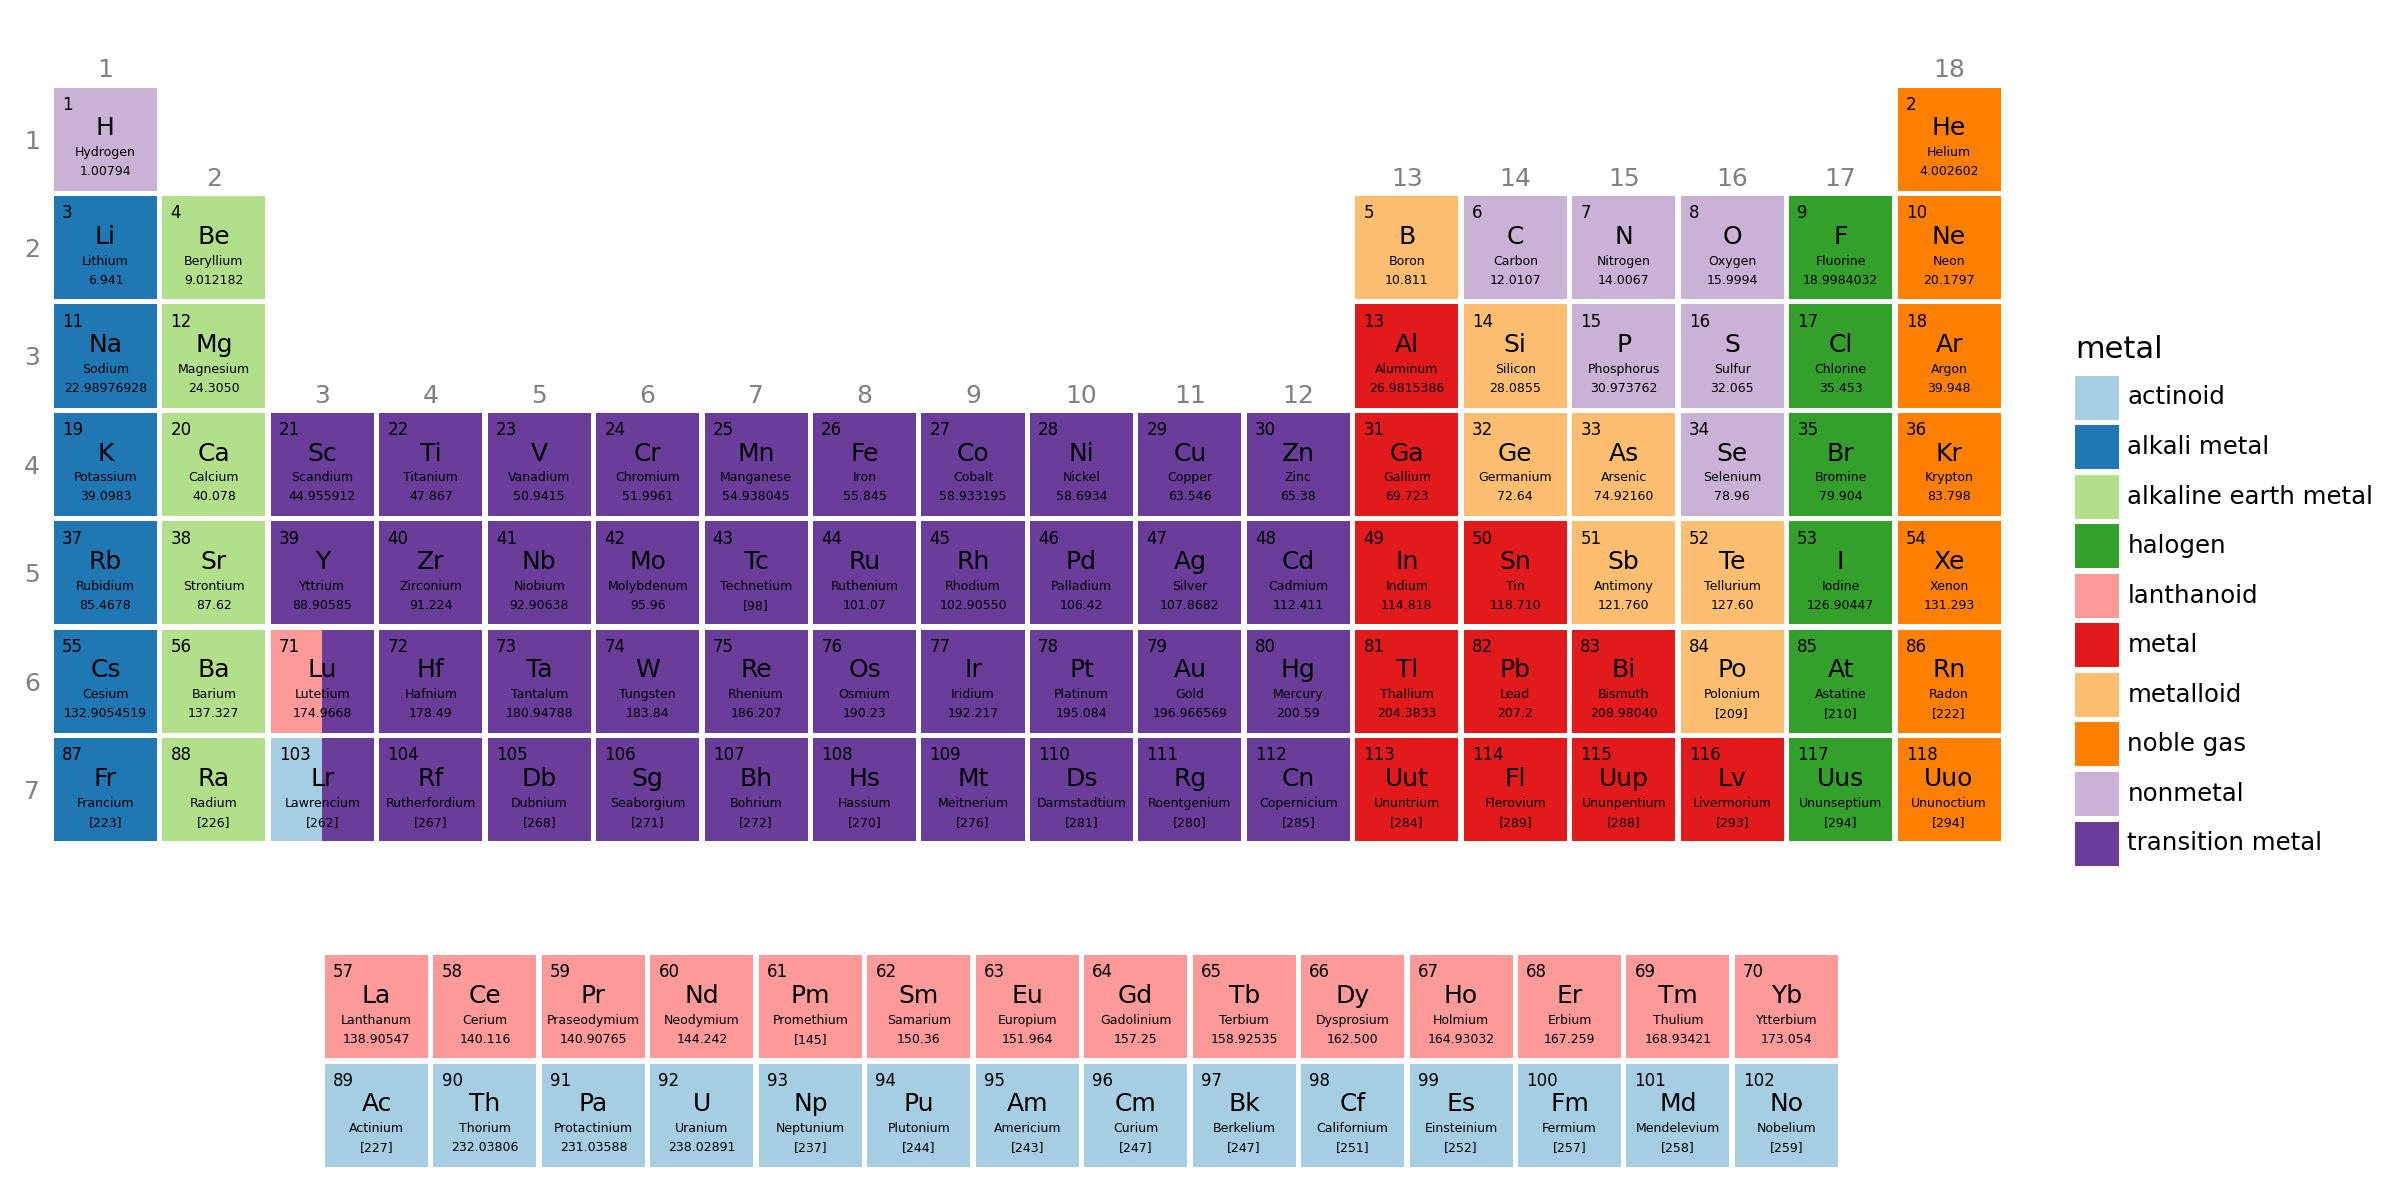

In [22]:
(
    ggplot(aes("x", "y"))
    + aes(fill="metal")
    + geom_tile(top, aes(width=tile_width, height=tile_height))
    + geom_tile(split_df, aes(width=tile_width / 2, height=tile_height))
    + geom_tile(bottom, aes(width=tile_width, height=tile_height))
    + inner_text(top)
    + inner_text(bottom)
    + geom_text(
        groupdf,
        aes("group", "y", label="group"),
        color="gray",
        nudge_y=0.525,
        va="bottom",
        fontweight="normal",
        size=9,
        inherit_aes=False,
    )  # new
    + scale_y_reverse(breaks=range(1, 8), limits=(0, 10.5))  # modified
    + scale_fill_brewer(type="qual", palette=3)
    + coord_equal(expand=False)
    + theme_void()
    + theme(
        figure_size=(12, 6),
        plot_margin_left=0.01,
        plot_margin_right=0.01,
        plot_background=element_rect(fill="white"),
        axis_text_y=element_text(margin={"r": 5}, color="gray", size=9),  # new
    )
)

